In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv( r"D:\A - Cac mon Ptit nam 4\Kỳ 2\Phân tích dữ liệu chuỗi thời gian\LichSuGia_DGC_12_01_2025_02_02_2026.csv",
            sep=";", encoding="utf-8-sig" )

#Lấy tên các cột cần thiết: Ngày + Gía điều chỉnh

df = df[["Ngay", "GiaDieuChinh"]]
df = df.rename(columns={ "Ngay": "Date", "GiaDieuChinh": "AdjClose" })

# Chuyển Date sang datetime
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)

# Sắp xếp theo thời gian
df = df.sort_values("Date")

# Set index
df.set_index("Date", inplace=True)

df.head()


['Ngay', 'GiaDieuChinh', 'GiaDongCua', 'ThayDoi', 'KhoiLuongKhopLenh', 'GiaTriKhopLenh', 'KLThoaThuan', 'GtThoaThuan', 'GiaMoCua', 'GiaCaoNhat', 'GiaThapNhat']


,AdjClose
Date,
2025-12-01,88.61
2025-12-02,90.29
2025-12-03,90.47
2025-12-04,90.47
2025-12-05,88.61


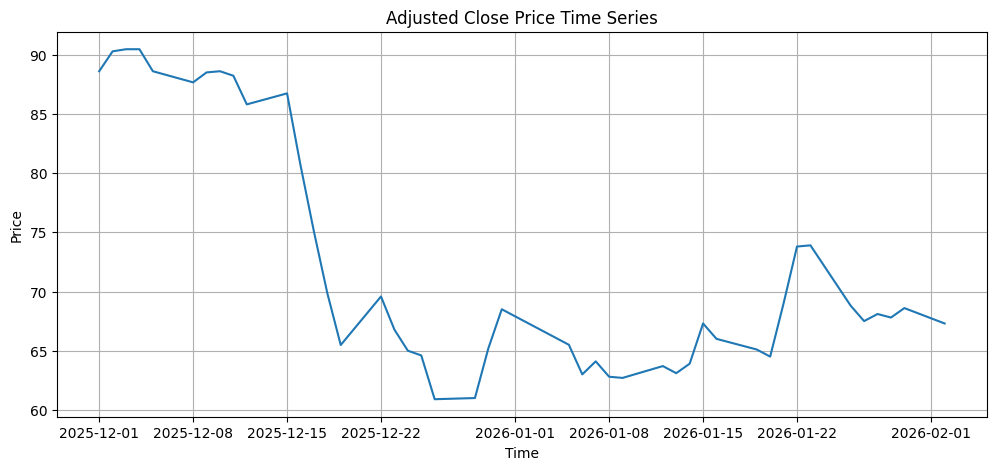

In [8]:
plt.figure(figsize=(12,5))
plt.plot(df.index, df["AdjClose"])
plt.title("Adjusted Close Price Time Series")
plt.xlabel("Time")
plt.ylabel("Price")
plt.grid(True)
plt.show()


In [ ]:
# Biến đổi log return để ổn định phương sai và đưa về gần các giá trị ổn định

df["LogReturn"] = np.log(df["AdjClose"] / df["AdjClose"].shift(1))

df.dropna(inplace=True)


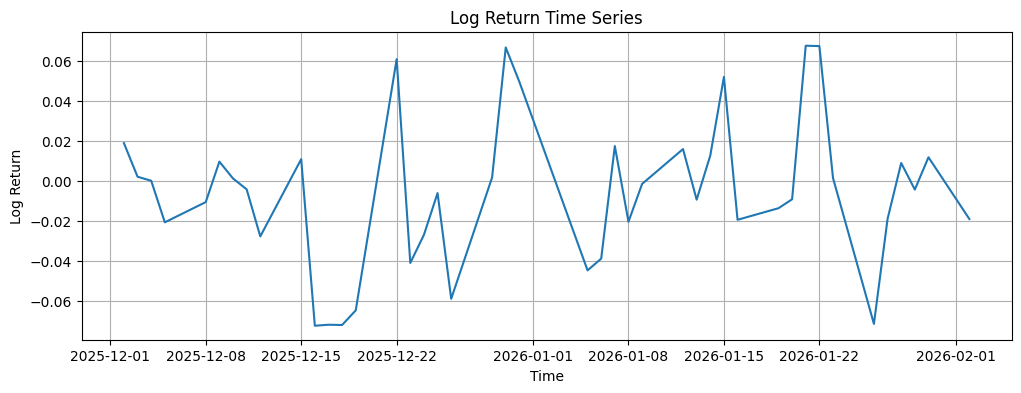

In [10]:
plt.figure(figsize=(12,4))
plt.plot(df.index, df["LogReturn"])
plt.title("Log Return Time Series")
plt.xlabel("Time")
plt.ylabel("Log Return")
plt.grid(True)
plt.show()


In [ ]:
#ADF test dùng để kiểm định tính dừng (stationarity) của chuỗi thời gian.
# ADF Price p-value = 0.2823 -> không dừng
# ADF Return p-value gần = 0 -> dừng

from statsmodels.tsa.stattools import adfuller

adf_price = adfuller(df["AdjClose"])
adf_return = adfuller(df["LogReturn"])

print("ADF Price p-value:", adf_price[1])
print("ADF Return p-value:", adf_return[1])

ADF Price p-value: 0.2823407803561944
ADF Return p-value: 4.770718893408277e-05
